In [6]:
import torch
import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print(" Path to dataset files:", path)

files = [
'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
'Monday-WorkingHours.pcap_ISCX.csv',
'Friday-WorkingHours-Morning.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
'Tuesday-WorkingHours.pcap_ISCX.csv',
'Wednesday-workingHours.pcap_ISCX.csv',
'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
       
       ]

dfs = []

for file in files:
    df = pd.read_csv(os.path.join(path, file))
    df.columns = df.columns.str.strip()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(data.shape)
print(data['Label'].value_counts())

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1
(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split FIRST before the scaler ever sees the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit scaler ONLY on training data, then apply to test separately
# This prevents test set statistics from leaking into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_train_t = torch.LongTensor(y_train.values)
y_test_t  = torch.LongTensor(y_test.values)

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.layers(x)

input_size = X_train_t.shape[1]
num_classes = len(y.unique())
model = NeuralNet(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=512, shuffle=True)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model.to(device)

for epoch in range(10):
    model.train()
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/10 Loss: {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        X_test_device = X_test_t.to(device)
        y_pred = model(X_test_device).argmax(dim=1).cpu().numpy()

    print(classification_report(y_test, y_pred))

Epoch 1/10 Loss: 0.0386


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99    454528
           1       0.00      0.00      0.00       389
           2       1.00      0.98      0.99     25484
           3       0.98      0.94      0.96      2085
           4       0.94      0.98      0.96     45987
           5       0.87      0.93      0.90      1139
           6       0.94      0.94      0.94      1179
           7       0.91      0.98      0.94      1574
           8       0.00      0.00      0.00         6
           9       0.00      0.00      0.00         5
          10       0.92      0.91      0.91     31574
          11       0.92      0.94      0.93      1183
          12       0.94      0.06      0.11       300
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       139

    accuracy                           0.98    565576
   macro avg       0.63      0.58      0.57    565576
weighted avg       0.98   

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99    454528
           1       0.57      0.60      0.59       389
           2       1.00      1.00      1.00     25484
           3       0.98      0.96      0.97      2085
           4       0.99      0.92      0.96     45987
           5       0.90      0.97      0.93      1139
           6       0.97      0.95      0.96      1179
           7       0.99      0.98      0.98      1574
           8       0.00      0.00      0.00         6
           9       0.67      0.40      0.50         5
          10       0.88      0.97      0.93     31574
          11       0.93      0.98      0.96      1183
          12       1.00      0.06      0.11       300
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       139

    accuracy                           0.98    565576
   macro avg       0.72      0.65      0.66    565576
weighted avg       0.98   

...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 9/10 Loss: 0.0121
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    454528
           1       0.58      0.34      0.43       389
           2       1.00      1.00      1.00     25484
           3       0.98      0.98      0.98      2085
           4       0.96      1.00      0.98     45987
           5       0.90      0.92      0.91      1139
           6       0.93      0.98      0.96      1179
           7       0.99      0.99      0.99      1574
           8       1.00      1.00      1.00         6
           9       1.00      0.40      0.57         5
          10       0.99      1.00      0.99     31574
          11       0.93      0.98      0.96      1183
          12       0.97      0.10      0.19       300
          13       0.00      0.00      0.00         4
          14       1.00      0.01      0.03       139

    accuracy                           0.99    565576
   macro avg       0.88      0.71      0.73    565576
we

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 10/10 Loss: 0.0252
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    454528
           1       0.98      0.34      0.50       389
           2       1.00      1.00      1.00     25484
           3       0.99      0.98      0.98      2085
           4       0.96      1.00      0.98     45987
           5       0.89      0.98      0.94      1139
           6       0.98      0.98      0.98      1179
           7       1.00      0.98      0.99      1574
           8       1.00      0.83      0.91         6
           9       1.00      0.60      0.75         5
          10       0.98      1.00      0.99     31574
          11       0.95      0.96      0.96      1183
          12       1.00      0.10      0.19       300
          13       0.00      0.00      0.00         4
          14       1.00      0.01      0.03       139

    accuracy                           0.99    565576
   macro avg       0.92      0.72      0.75    565576
w

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


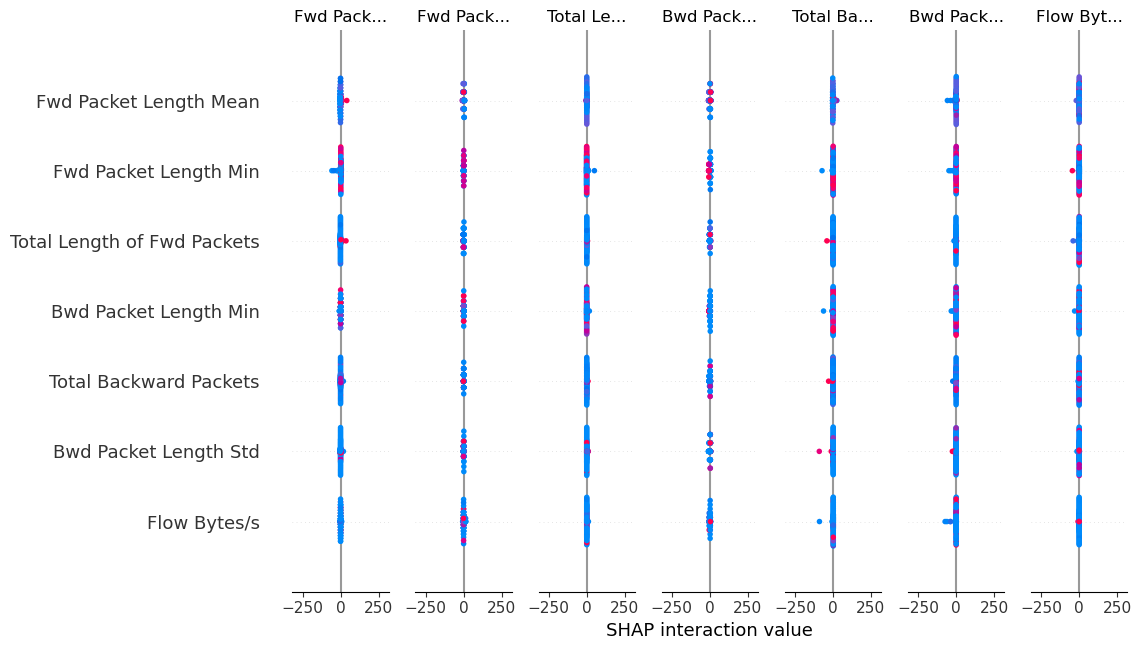

In [9]:
import matplotlib.pyplot as plt
import shap

model.to('cpu')
X_train_cpu = X_train_t[:100].to("cpu")
X_test_cpu  = X_test_t[:100].to('cpu')
explainer = shap.DeepExplainer(model, X_train_cpu)
shap_values = explainer.shap_values(X_test_cpu)
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=X.columns, class_names=le.classes_, show=False)
plt.tight_layout()
plt.show()

In [ ]:
'''POWERBI EXPORT'''
import sqlite3

con = sqlite3.connect('/Users/antoniogonzalez/Desktop/CIC_IDS_2017_FOLD/CONCAT/CIC_IDS_2017.db')

df = pd.read_sql("""
    SELECT
          "Label",
          "Destination Port",
          "Flow Duration",
          "Total Fwd Packets",
          "Total Backward Packets",
          "Flow Bytes/s",
          "Flow Packets/s",
          "Fwd Packet Length Mean",
          "Bwd Packet Length Mean"
    FROM network_traffic
    """, con)
con.close()

def categorize(label):
    if label == 'BENIGN':
        return 'BENIGN'
    elif label.startswith('DoS') or label == 'DDoS':
        return 'DoS/DDoS'
    elif label.startswith('Web Attack'):
        return 'Web Attack'
    elif 'Patator' in label:
        return 'Brute Force'
    elif label == 'PortScan':
        return 'Reconnaissance'
    elif label == 'Bot':
        return 'Bot'
    else:
        return 'Other'

df['Attack Category'] = df['Label'].apply(categorize)

#Hide df export to computer --- IGNORE ---
print(f"Exported {len(df):,} rows")
print(df['Attack Category'].value_counts())

Exported 2,830,743 rows
Attack Category
BENIGN            2273097
DoS/DDoS           380688
Reconnaissance     158930
Brute Force         13835
Web Attack           2180
Bot                  1966
Other                  47
Name: count, dtype: int64
